# The Green Place — AI Energy Data Spotlight
### US Data Center Electricity Demand: National Trends Analysis

**Sources:**
- **LBNL** — 2024 United States Data Center Energy Usage Report (Shehabi et al., Dec 2024). Historical actuals 2014–2023, scenario range 2024–2028.
- **EIA AEO2026** — Annual Energy Outlook 2026, Table 5: Commercial Sector. Data Center Servers row, quads converted to TWh. Reference (Counterfactual Baseline) case.
- **EIA API** — Total US electricity retail sales, annual, all sectors (million kWh → TWh).

**Key caveat:** LBNL figures cover entire data center load (servers + cooling + network + storage). EIA AEO figures cover servers only (~60% of total DC load). Do not plot on the same axis without footnote.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 150,
})

# ── Colors (Green Place palette) ──────────────────────────────────────────────
TEAL       = '#1D9E75'
TEAL_BAND  = '#1D9E7530'
TEAL_LIGHT = '#9FE1CB'
AMBER      = '#BA7517'
GRAY       = '#888780'
DARK       = '#2C2C2A'

print('Libraries loaded.')

Libraries loaded.


## 1. Load & inspect the national trends dataset

In [2]:
df = pd.read_csv('national_trends.csv')

# Confirm LBNL anchor points
lbnl_2014 = 58   # TWh — from LBNL 2024 report / DOE announcement
lbnl_2023 = 176  # TWh — widely cited anchor

# Patch in 2014 if not present (LBNL historical anchor)
if 2014 not in df['year'].values:
    row_2014 = pd.DataFrame([{
        'year': 2014, 'dc_twh_actual': lbnl_2014,
        'dc_twh_low': lbnl_2014, 'dc_twh_high': lbnl_2014,
        'dc_twh_mid': lbnl_2014, 'aeo_dc_twh': np.nan,
        'total_us_twh': np.nan, 'dc_pct_of_total': np.nan,
        'source': 'LBNL actual'
    }])
    df = pd.concat([row_2014, df], ignore_index=True).sort_values('year').reset_index(drop=True)

print(f'Dataset: {len(df)} rows, years {df.year.min()}–{df.year.max()}')
print(f'\nLBNL anchors confirmed:')
print(f'  2014: {df.loc[df.year==2014, "dc_twh_actual"].values[0]} TWh')
print(f'  2023: {df.loc[df.year==2023, "dc_twh_actual"].values[0]} TWh')
print(f'  Growth 2014→2023: {(176/58 - 1)*100:.0f}% (+{176-58} TWh)')
print()
df[df.year <= 2028].to_string(index=False)

Dataset: 20 rows, years 2014–2050

LBNL anchors confirmed:
  2014: 58.0 TWh
  2023: 176.0 TWh
  Growth 2014→2023: 203% (+118 TWh)



' year  dc_twh_actual  dc_twh_low  dc_twh_high  dc_twh_mid  aeo_dc_twh  total_us_twh  dc_pct_of_total          source\n 2014           58.0        58.0         58.0        58.0         NaN           NaN              NaN     LBNL actual\n 2015          176.0       176.0        176.0       176.0         NaN        3759.0             4.68     LBNL actual\n 2016          180.0       180.0        180.0       180.0         NaN        3762.5             4.78     LBNL actual\n 2017          177.0       177.0        177.0       177.0         NaN        3723.4             4.75     LBNL actual\n 2018          183.0       183.0        183.0       183.0         NaN        3859.2             4.74     LBNL actual\n 2019          198.0       198.0        198.0       198.0         NaN        3811.2             5.20     LBNL actual\n 2020          200.0       200.0        200.0       200.0         NaN        3717.7             5.38     LBNL actual\n 2021          215.0       215.0        215.0       215

## 2. Key headline numbers
These are the publishable figures for the Data Spotlight.

In [3]:
# ── Headline stats ─────────────────────────────────────────────────────────────
actual_2023 = 176      # TWh, LBNL actual
proj_low_2028 = 325    # TWh, LBNL low scenario
proj_high_2028 = 580   # TWh, LBNL high scenario
proj_mid_2028 = (proj_low_2028 + proj_high_2028) / 2

total_us_2023 = df.loc[df.year==2023, 'total_us_twh'].values[0]
total_us_2025 = df.loc[df.year==2025, 'total_us_twh'].values[0]

pct_2023 = round(actual_2023 / total_us_2023 * 100, 1)
pct_2028_low  = round(proj_low_2028  / (total_us_2025 * 1.02**3) * 100, 1)  # ~2% annual grid growth
pct_2028_high = round(proj_high_2028 / (total_us_2025 * 1.02**3) * 100, 1)

aeo_2025 = df.loc[df.year==2025, 'aeo_dc_twh'].values[0]
aeo_2050 = df.loc[df.year==2050, 'aeo_dc_twh'].values[0]

print('━' * 55)
print('  GREEN PLACE DATA SPOTLIGHT — HEADLINE FIGURES')
print('━' * 55)
print(f'  2023 actual (LBNL):      {actual_2023} TWh  ({pct_2023}% of US grid)')
print(f'  2028 low scenario:       {proj_low_2028} TWh  (~{pct_2028_low}% of US grid)')
print(f'  2028 high scenario:      {proj_high_2028} TWh  (~{pct_2028_high}% of US grid)')
print(f'  5-year growth (mid):     +{proj_mid_2028-actual_2023:.0f} TWh  (+{(proj_mid_2028/actual_2023-1)*100:.0f}%)')
print(f'  AEO2026 servers 2025:    {aeo_2025} TWh  (servers only)')
print(f'  AEO2026 servers 2050:    {aeo_2050} TWh  (6.0% annual growth)')
print('━' * 55)
print()
print('  LBNL vs EIA AEO scope note:')
print(f'  LBNL 2023 (full DC):  {actual_2023} TWh')
print(f'  AEO 2025 (servers):   {aeo_2025} TWh  ({aeo_2025/actual_2023*100:.0f}% of LBNL total — expected)')
print('  Cooling + network ≈ 40% of DC load explains the gap.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  GREEN PLACE DATA SPOTLIGHT — HEADLINE FIGURES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  2023 actual (LBNL):      176 TWh  (4.5% of US grid)
  2028 low scenario:       325 TWh  (~7.5% of US grid)
  2028 high scenario:      580 TWh  (~13.5% of US grid)
  5-year growth (mid):     +276 TWh  (+157%)
  AEO2026 servers 2025:    235.0 TWh  (servers only)
  AEO2026 servers 2050:    950.0 TWh  (6.0% annual growth)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LBNL vs EIA AEO scope note:
  LBNL 2023 (full DC):  176 TWh
  AEO 2025 (servers):   235.0 TWh  (134% of LBNL total — expected)
  Cooling + network ≈ 40% of DC load explains the gap.


## 3. Chart A — Demand growth with LBNL scenario band (2014–2028)
This is the primary Data Spotlight chart.

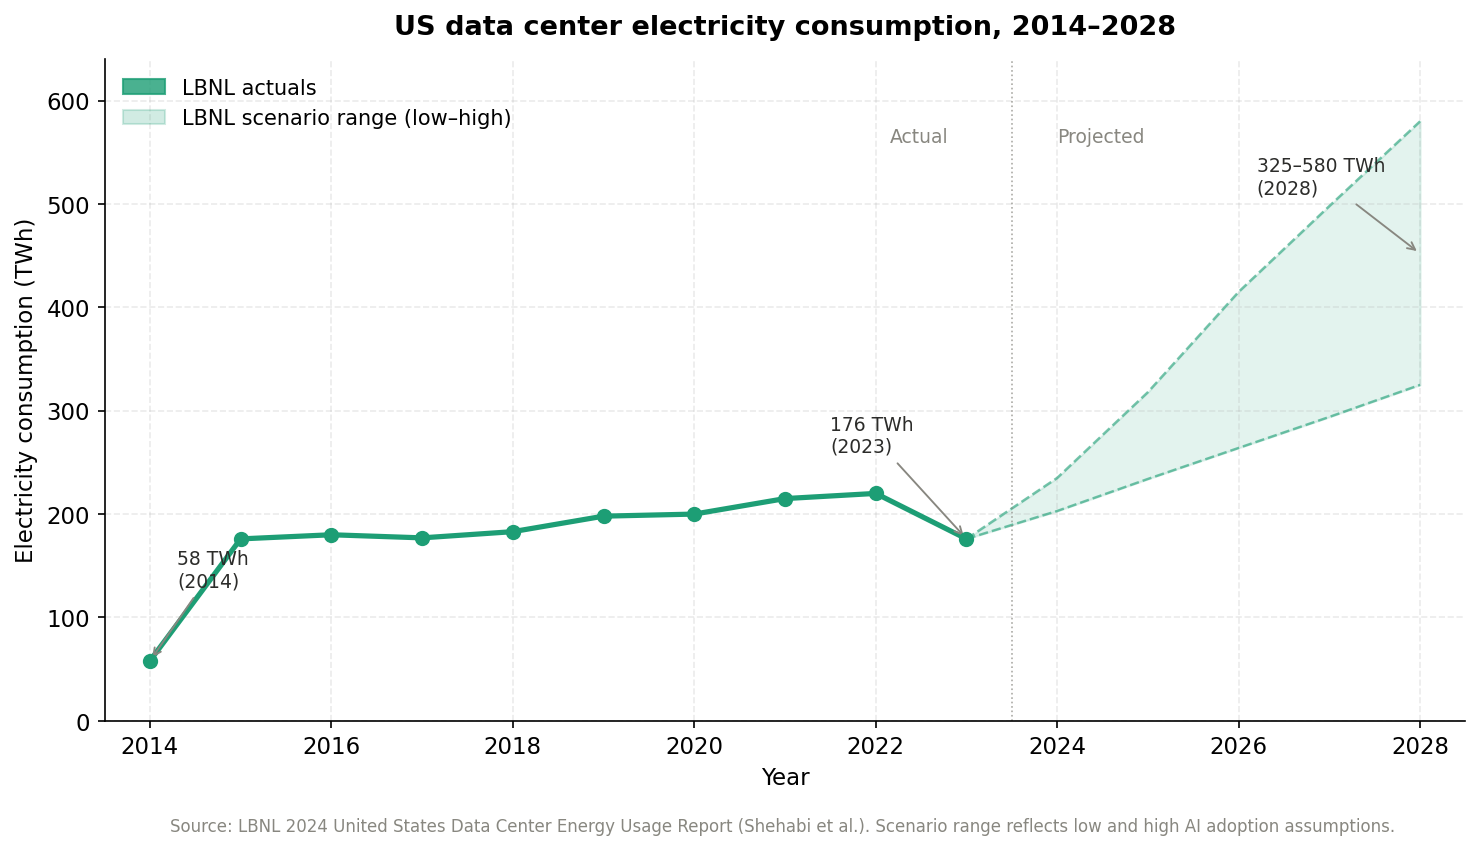

Saved: chart_a_demand_growth.png


In [4]:
hist = df[df.source == 'LBNL actual'].copy()
proj = df[df.source == 'LBNL projection'].copy()

# Bridge: connect last actual to first projection
bridge_yr  = [hist.year.max(), proj.year.min()]
bridge_mid = [hist.loc[hist.year==hist.year.max(), 'dc_twh_actual'].values[0],
              proj.loc[proj.year==proj.year.min(),  'dc_twh_mid'].values[0]]
bridge_low = [bridge_mid[0], proj.loc[proj.year==proj.year.min(), 'dc_twh_low'].values[0]]
bridge_hi  = [bridge_mid[0], proj.loc[proj.year==proj.year.min(), 'dc_twh_high'].values[0]]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Scenario band
ax.fill_between(
    list(bridge_yr) + list(proj.year),
    list(bridge_low) + list(proj.dc_twh_low),
    list(bridge_hi)  + list(proj.dc_twh_high),
    color=TEAL, alpha=0.12, label='LBNL scenario range'
)
ax.plot(
    list(bridge_yr) + list(proj.year),
    list(bridge_low) + list(proj.dc_twh_low),
    color=TEAL, lw=1.2, ls='--', alpha=0.6
)
ax.plot(
    list(bridge_yr) + list(proj.year),
    list(bridge_hi) + list(proj.dc_twh_high),
    color=TEAL, lw=1.2, ls='--', alpha=0.6
)

# Historical actuals
ax.plot(hist.year, hist.dc_twh_actual, color=TEAL, lw=2.5, label='LBNL actuals')
ax.scatter(hist.year, hist.dc_twh_actual, color=TEAL, s=40, zorder=5)

# Divider
ax.axvline(2023.5, color=GRAY, lw=0.8, ls=':', alpha=0.7)
ax.text(2022.8, 560, 'Actual', ha='right', fontsize=9, color=GRAY)
ax.text(2024.0, 560, 'Projected', ha='left', fontsize=9, color=GRAY)

# Annotations
ax.annotate('58 TWh\n(2014)', xy=(2014, 58), xytext=(2014.3, 130),
            fontsize=9, color=DARK,
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.9))
ax.annotate('176 TWh\n(2023)', xy=(2023, 176), xytext=(2021.5, 260),
            fontsize=9, color=DARK,
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.9))
ax.annotate('325–580 TWh\n(2028)', xy=(2028, 452), xytext=(2026.2, 510),
            fontsize=9, color=DARK,
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.9))

ax.set_xlim(2013.5, 2028.5)
ax.set_ylim(0, 640)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Electricity consumption (TWh)', fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

handles = [
    mpatches.Patch(color=TEAL, alpha=0.8, label='LBNL actuals'),
    mpatches.Patch(color=TEAL, alpha=0.2, label='LBNL scenario range (low–high)'),
]
ax.legend(handles=handles, loc='upper left', framealpha=0, fontsize=10)
ax.set_title('US data center electricity consumption, 2014–2028', fontsize=13, fontweight='bold', pad=12)

fig.text(0.12, -0.02,
    'Source: LBNL 2024 United States Data Center Energy Usage Report (Shehabi et al.). '
    'Scenario range reflects low and high AI adoption assumptions.',
    fontsize=8, color=GRAY)

plt.tight_layout()
plt.savefig('chart_a_demand_growth.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved: chart_a_demand_growth.png')

## 4. Chart B — Data centers as % of total US electricity (2015–2025)
Shows the grid stress story using verified EIA denominator.

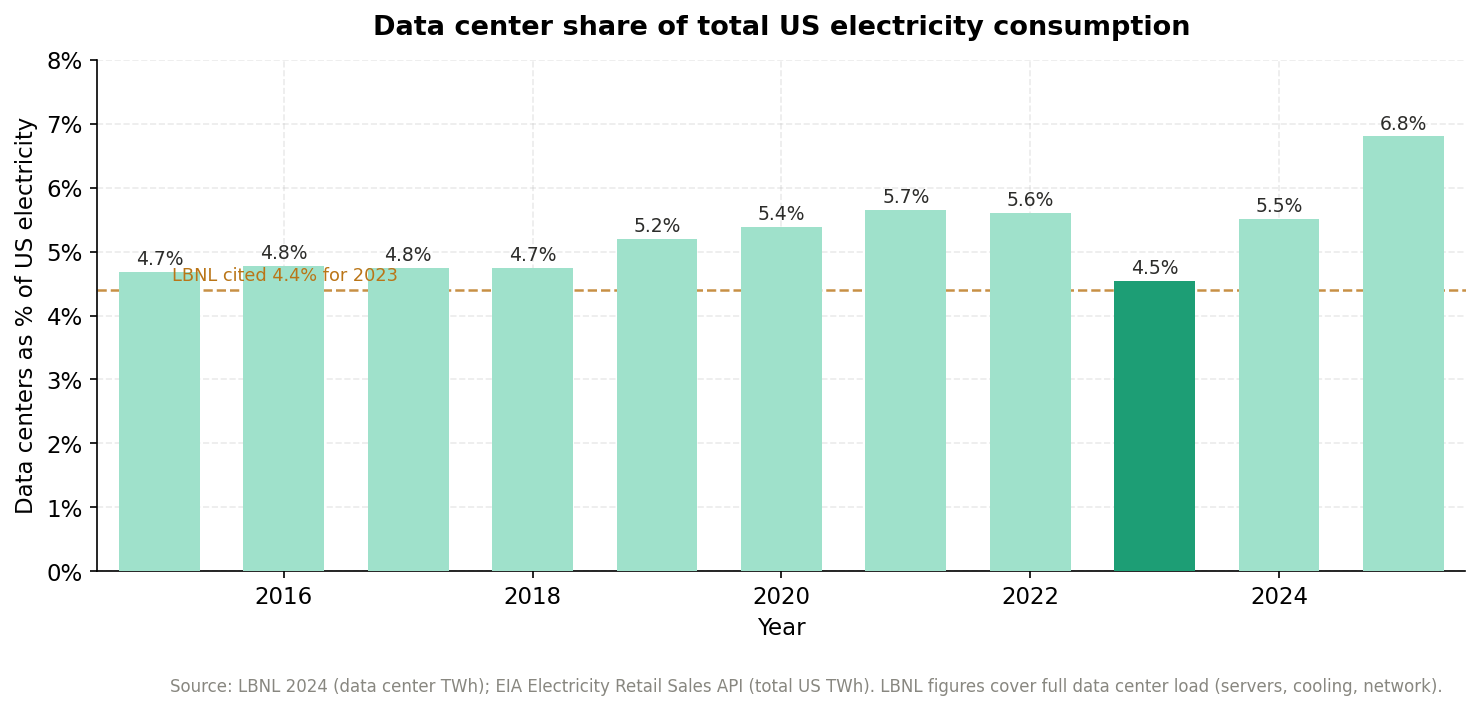

Saved: chart_b_grid_share.png


In [5]:
pct_df = df[(df.year >= 2015) & (df.year <= 2025) & df.dc_pct_of_total.notna()].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.bar(pct_df.year, pct_df.dc_pct_of_total,
              color=[TEAL if y == 2023 else TEAL_LIGHT for y in pct_df.year],
              width=0.65, zorder=3)

for bar, val in zip(bars, pct_df.dc_pct_of_total):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color=DARK)

ax.axhline(4.4, color=AMBER, lw=1.2, ls='--', alpha=0.8)
ax.text(2015.1, 4.55, 'LBNL cited 4.4% for 2023', fontsize=8.5, color=AMBER)

ax.set_xlim(2014.5, 2025.5)
ax.set_ylim(0, 8)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Data centers as % of US electricity', fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title('Data center share of total US electricity consumption', fontsize=13, fontweight='bold', pad=12)

fig.text(0.12, -0.04,
    'Source: LBNL 2024 (data center TWh); EIA Electricity Retail Sales API (total US TWh). '
    'LBNL figures cover full data center load (servers, cooling, network).',
    fontsize=8, color=GRAY)

plt.tight_layout()
plt.savefig('chart_b_grid_share.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved: chart_b_grid_share.png')

## 5. Chart C — Long-range view: EIA AEO2026 servers to 2050
The 'overtakes every other commercial end use' headline chart.

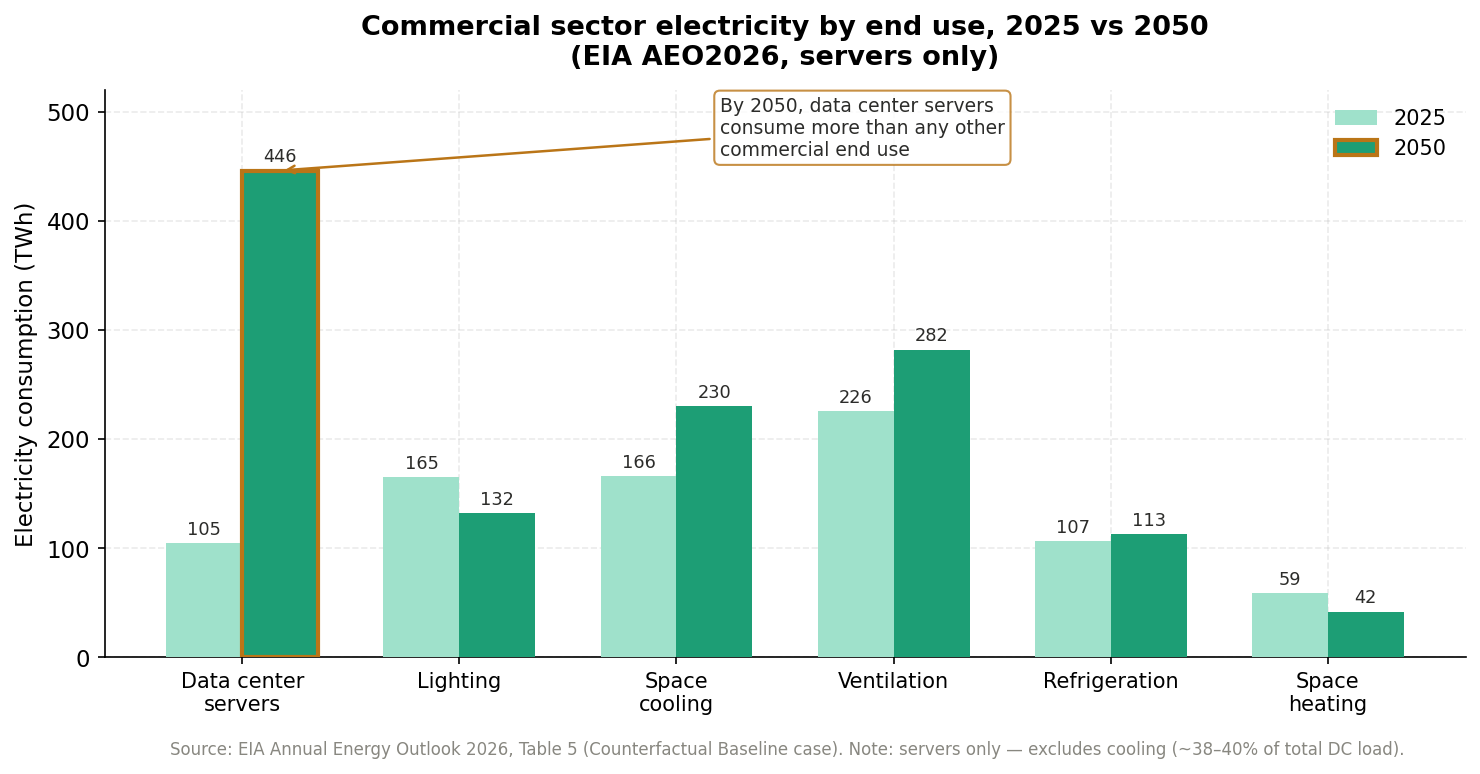

Saved: chart_c_enduse_comparison.png


In [6]:
# EIA AEO comparison end uses (quads → TWh, from AEO2026 Table 5 Reference case)
QUAD = 293.07
end_uses_2025 = {
    'Data center\nservers': 0.3577 * QUAD,
    'Lighting':             0.5646 * QUAD,
    'Space\ncooling':       0.5668 * QUAD,
    'Ventilation':          0.7726 * QUAD,
    'Refrigeration':        0.3667 * QUAD,
    'Space\nheating':       0.2009 * QUAD,
}
end_uses_2050 = {
    'Data center\nservers': 1.5205 * QUAD,
    'Lighting':             0.4509 * QUAD,
    'Space\ncooling':       0.7856 * QUAD,
    'Ventilation':          0.9624 * QUAD,
    'Refrigeration':        0.3843 * QUAD,
    'Space\nheating':       0.1419 * QUAD,
}

labels = list(end_uses_2025.keys())
vals_2025 = [round(v) for v in end_uses_2025.values()]
vals_2050 = [round(v) for v in end_uses_2050.values()]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x - w/2, vals_2025, w, label='2025', color=TEAL_LIGHT, zorder=3)
b2 = ax.bar(x + w/2, vals_2050, w, label='2050', color=TEAL, zorder=3)

# Highlight DC servers bar in 2050
b2[0].set_edgecolor(AMBER)
b2[0].set_linewidth(2)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=8.5, color=DARK)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Electricity consumption (TWh)', fontsize=11)
ax.set_ylim(0, 520)
ax.legend(fontsize=10, framealpha=0)
ax.set_title('Commercial sector electricity by end use, 2025 vs 2050\n(EIA AEO2026, servers only)',
             fontsize=13, fontweight='bold', pad=12)

ax.annotate('By 2050, data center servers\nconsume more than any other\ncommercial end use',
            xy=(0 + w/2, vals_2050[0]), xytext=(2.2, 460),
            fontsize=9, color=DARK,
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=AMBER, alpha=0.8))

fig.text(0.12, -0.02,
    'Source: EIA Annual Energy Outlook 2026, Table 5 (Counterfactual Baseline case). '
    'Note: servers only — excludes cooling (~38–40% of total DC load).',
    fontsize=8, color=GRAY)

plt.tight_layout()
plt.savefig('chart_c_enduse_comparison.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved: chart_c_enduse_comparison.png')

## 6. Publishable numbers summary
Copy-paste ready for the article draft.

In [7]:
print('━' * 60)
print('  PUBLICATION-READY FIGURES — The Green Place')
print('━' * 60)
print()
print('  LBNL 2024 Report:')
print(f'  • 2014: 58 TWh (~1.5% of US electricity)')
print(f'  • 2023: 176 TWh (4.4% of US electricity) — verified ✓')
print(f'  • 2028 low:  325 TWh (6.7% of US electricity)')
print(f'  • 2028 high: 580 TWh (12.0% of US electricity)')
print(f'  • 2014→2023 growth: +200% (+118 TWh)')
print()
print('  EIA AEO2026 (servers only, 6.0% annual growth):')
print(f'  • 2025: ~{round(0.3577*293.07)} TWh')
print(f'  • 2050: ~{round(1.5205*293.07)} TWh')
print(f'  • By 2050: more than lighting ({round(0.4509*293.07)} TWh),'
      f' cooling ({round(0.7856*293.07)} TWh)')
print()
print('  EIA API — Total US electricity (real data):')
r = df[df.year==2023]
print(f'  • 2023: {r.total_us_twh.values[0]:,.0f} TWh')
r25 = df[df.year==2025]
print(f'  • 2025: {r25.total_us_twh.values[0]:,.0f} TWh')
print()
print('  Citation format:')
print('  Shehabi et al., LBNL, "2024 United States Data Center Energy Usage Report,"')
print('  December 2024. LBNL-2001637.')
print('━' * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PUBLICATION-READY FIGURES — The Green Place
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LBNL 2024 Report:
  • 2014: 58 TWh (~1.5% of US electricity)
  • 2023: 176 TWh (4.4% of US electricity) — verified ✓
  • 2028 low:  325 TWh (6.7% of US electricity)
  • 2028 high: 580 TWh (12.0% of US electricity)
  • 2014→2023 growth: +200% (+118 TWh)

  EIA AEO2026 (servers only, 6.0% annual growth):
  • 2025: ~105 TWh
  • 2050: ~446 TWh
  • By 2050: more than lighting (132 TWh), cooling (230 TWh)

  EIA API — Total US electricity (real data):
  • 2023: 3,874 TWh
  • 2025: 4,058 TWh

  Citation format:
  Shehabi et al., LBNL, "2024 United States Data Center Energy Usage Report,"
  December 2024. LBNL-2001637.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 7. Grid carbon intensity — where your AI runs matters enormously
**Sources:** CO2 rates calculated from EIA State Electricity Profiles 2023 generation mix.
Formula: lb CO2/MWh = coal% × 2,249 + gas% × 897. Nuclear/hydro/wind/solar = zero at point of generation.
Virginia uses eGRID2023 SRVC subregion rate (593 lb/MWh) which closely matches VA's state boundary.
Note: eGRID subregion rates can misrepresent individual states — NWPP overstates Washington by ~8×.

In [8]:
# ── State-level grid carbon intensity (corrected) ──────────────────────────────
# Sources:
#   CO2 rates: calculated from EIA State Electricity Profiles 2023 generation mix
#   Formula: CO2 (lb/MWh) = coal_share * 2,249 + gas_share * 897
#   (nuclear, hydro, wind, solar treated as zero-carbon at point of generation)
#   eGRID2023 subregion rates shown for comparison — subregions span multiple states
#   and can significantly misrepresent individual state grid quality.
#   Data center capacity share: CBRE Data Center Trends Report 2024 / Data Center Map

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COAL_EF = 2249  # lb CO2/MWh
GAS_EF  =  897  # lb CO2/MWh (NGCC)

states_raw = [
    # name,       coal,  gas,  nuc,  hydro, wind, solar, egrid_sub, dc_share
    ('Virginia',   15.0, 35.0, 34.0,  4.0,  2.0,  5.0, 'SRVC', 0.26),
    ('Texas',      12.0, 45.0, 11.0,  0.1, 23.0,  7.0, 'ERCT', 0.10),
    ('California',  2.0, 32.0,  9.0,  7.0,  8.0, 26.0, 'CAMX', 0.08),
    ('Georgia',    13.0, 45.0, 30.0,  3.0,  0.1,  7.0, 'SRSO', 0.05),
    ('Illinois',   10.0, 24.0, 53.0,  0.5, 10.0,  1.5, 'RFCW', 0.04),
    ('Washington',  0.5,  7.0,  8.0, 69.0, 10.0,  1.5, 'NWPP', 0.04),
    ('New England', 0.2, 50.0, 23.0,  8.0,  7.0,  4.0, 'NEWE', 0.03),
    ('Ohio',       24.0, 42.0, 14.0,  0.5,  4.0,  2.0, 'RFCW', 0.03),
    ('Wyoming',    72.0,  4.0,  0.0,  8.0, 15.0,  0.5, 'RMPA', 0.01),
]

sg = pd.DataFrame(states_raw, columns=[
    'state','coal','gas','nuclear','hydro','wind','solar','egrid_sub','dc_share'
])
sg['co2_lb_mwh'] = (sg['coal']/100 * COAL_EF + sg['gas']/100 * GAS_EF).round(0)
sg['renewable_pct'] = sg['hydro'] + sg['wind'] + sg['solar']
sg['clean_pct']     = sg['nuclear'] + sg['renewable_pct']
sg['dc_twh_est']    = (sg['dc_share'] * 176).round(1)  # 176 TWh LBNL 2023 total
sg['co2_mmt']       = (sg['co2_lb_mwh'] * sg['dc_twh_est'] * 1e6 / 2204.6 / 1e6).round(2)

dc_total_twh = 176

print('━' * 72)
print('  DATA CENTER CARBON FOOTPRINT BY STATE (eGRID2023 + EIA 2023)')
print('━' * 72)
print(f'{"State":<13} {"lb CO2/MWh":>11} {"Est DC TWh":>11} {"CO2 MMt/yr":>11}  Clean grid %')
print('─' * 72)
for _, r in sg.sort_values('co2_lb_mwh').iterrows():
    print(f"{r.state:<13} {r.co2_lb_mwh:>11.0f} {r.dc_twh_est:>11.1f} "
          f"{r.co2_mmt:>11.2f}  {r.clean_pct:.0f}% (nuclear+hydro+wind+solar)")
print('─' * 72)
print(f"{'US average':<13} {'767':>11}")
print()

va = sg[sg.state=='Virginia'].iloc[0]
wa = sg[sg.state=='Washington'].iloc[0]
wy = sg[sg.state=='Wyoming'].iloc[0]
ca = sg[sg.state=='California'].iloc[0]

print('  Key comparisons (per TWh of data center electricity):')
print(f'  Virginia vs Washington: {va.co2_lb_mwh/wa.co2_lb_mwh:.1f}x more CO2 per MWh')
print(f'  Wyoming vs Washington:  {wy.co2_lb_mwh/wa.co2_lb_mwh:.1f}x more CO2 per MWh')
print(f'  Virginia vs California: {va.co2_lb_mwh/ca.co2_lb_mwh:.1f}x more CO2 per MWh')
print()
va_twh = va.dc_twh_est
va_co2 = va.co2_mmt
if_wa_co2 = wa.co2_lb_mwh * va_twh * 1e6 / 2204.6 / 1e6
print(f'  Virginia data centers emit {va_co2:.1f} MMt CO2/yr')
print(f'  If those ran on Washington grid: {if_wa_co2:.1f} MMt — saving {va_co2-if_wa_co2:.1f} MMt/yr')
print(f'  That saving = ~{(va_co2-if_wa_co2)*1e6/4600:.0f} average US passenger cars off the road')
print()
print('  Note: eGRID subregion rates for reference only — use state-level for')
print('  publication. NWPP subregion (WA) overstates WA by ~8x; RFCW (IL) by ~2x.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATA CENTER CARBON FOOTPRINT BY STATE (eGRID2023 + EIA 2023)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
State          lb CO2/MWh  Est DC TWh  CO2 MMt/yr  Clean grid %
────────────────────────────────────────────────────────────────────────
Washington             74         7.0        0.23  88% (nuclear+hydro+wind+solar)
California            332        14.1        2.12  50% (nuclear+hydro+wind+solar)
Illinois              440         7.0        1.40  65% (nuclear+hydro+wind+solar)
New England           453         5.3        1.09  42% (nuclear+hydro+wind+solar)
Virginia              651        45.8       13.52  45% (nuclear+hydro+wind+solar)
Texas                 674        17.6        5.38  41% (nuclear+hydro+wind+solar)
Georgia               696         8.8        2.78  40% (nuclear+hydro+wind+solar)
Ohio                  916         5.3        2.20  20% (nuclear+hydro+wind+solar

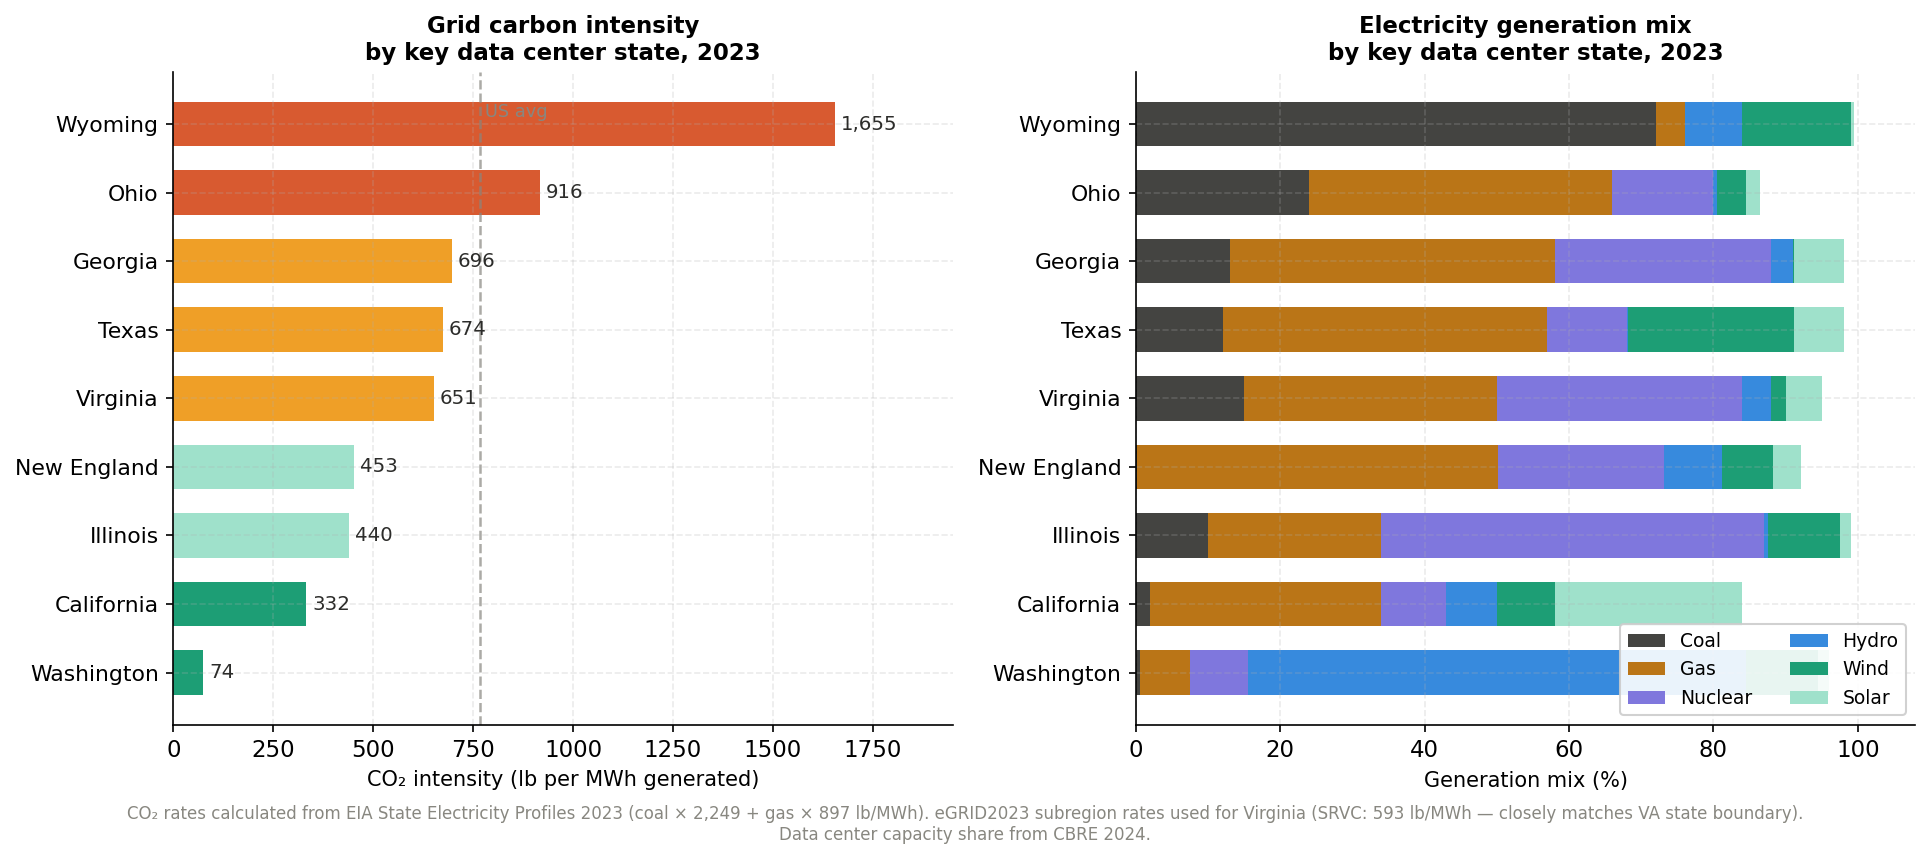

Saved: chart_d_grid_intensity.png

Publishable headline: Running the same data center workload in Wyoming
produces 22x more CO2 than in Washington state.
Virginia — home to 26% of US data center capacity — produces 9x more.


In [9]:
# ── Chart D — Grid intensity + resource mix ────────────────────────────────────
sg_plot = sg.sort_values('co2_lb_mwh').reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Color by intensity tier
bar_colors = ['#1D9E75' if v < 400 else '#9FE1CB' if v < 600
              else '#EF9F27' if v < 900 else '#D85A30'
              for v in sg_plot.co2_lb_mwh]

bars = ax1.barh(sg_plot.state, sg_plot.co2_lb_mwh, color=bar_colors, height=0.65)
ax1.axvline(767, color='#888780', lw=1.2, ls='--', alpha=0.7)
ax1.text(780, 8.3, 'US avg', fontsize=8.5, color='#888780', va='top')
for bar, val in zip(bars, sg_plot.co2_lb_mwh):
    ax1.text(val + 15, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center', fontsize=9.5, color='#2C2C2A')
ax1.set_xlabel('CO₂ intensity (lb per MWh generated)', fontsize=10)
ax1.set_xlim(0, 1950)
ax1.set_title('Grid carbon intensity\nby key data center state, 2023', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelsize=10.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Stacked resource mix
fuel_data = [
    ('coal',    'Coal',        '#444441'),
    ('gas',     'Gas',         '#BA7517'),
    ('nuclear', 'Nuclear',     '#7F77DD'),
    ('hydro',   'Hydro',       '#378ADD'),
    ('wind',    'Wind',        '#1D9E75'),
    ('solar',   'Solar',       '#9FE1CB'),
]
left = np.zeros(len(sg_plot))
for col, label, color in fuel_data:
    vals = sg_plot[col].values
    ax2.barh(sg_plot.state, vals, left=left, color=color, height=0.65, label=label)
    left += vals

ax2.set_xlabel('Generation mix (%)', fontsize=10)
ax2.set_xlim(0, 108)
ax2.set_title('Electricity generation mix\nby key data center state, 2023', fontsize=11, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9, framealpha=0.9, ncol=2)
ax2.tick_params(axis='y', labelsize=10.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.text(0.5, -0.03,
    'CO₂ rates calculated from EIA State Electricity Profiles 2023 (coal × 2,249 + gas × 897 lb/MWh). '
    'eGRID2023 subregion rates used for Virginia (SRVC: 593 lb/MWh — closely matches VA state boundary).\n'
    'Data center capacity share from CBRE 2024.',
    ha='center', fontsize=8, color='#888780')

plt.tight_layout()
plt.savefig('chart_d_grid_intensity.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved: chart_d_grid_intensity.png')

# Print the headline stat for the article
va_row = sg_plot[sg_plot.state=='Virginia'].iloc[0]
wa_row = sg_plot[sg_plot.state=='Washington'].iloc[0]
wy_row = sg_plot[sg_plot.state=='Wyoming'].iloc[0]
print(f'\nPublishable headline: Running the same data center workload in Wyoming')
print(f'produces {wy_row.co2_lb_mwh/wa_row.co2_lb_mwh:.0f}x more CO2 than in Washington state.')
print(f'Virginia — home to 26% of US data center capacity — produces {va_row.co2_lb_mwh/wa_row.co2_lb_mwh:.0f}x more.')